In [1]:
# Import libraries
from pprint import pprint
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import TextClassificationPipeline
from datasets import load_dataset

# Suppress warnings
warnings.filterwarnings("ignore")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set up plotting
plt.style.use('ggplot')
sns.set(style="whitegrid")

# Set the device for pytorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load pre-trained model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move to GPU if available
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"Model: {model_name}")
print(f"Device: {device}")

# Load a small test dataset (SST-2)
test_dataset = load_dataset("glue", "sst2", split="validation[:500]")
print(f"Test dataset loaded: {len(test_dataset)} examples")

Model: distilbert-base-uncased-finetuned-sst-2-english
Device: cpu
Test dataset loaded: 500 examples


In [3]:
model.config

DistilBertConfig {
  "_attn_implementation_autoset": true,
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "finetuning_task": "sst-2",
  "hidden_dim": 3072,
  "id2label": {
    "0": "NEGATIVE",
    "1": "POSITIVE"
  },
  "initializer_range": 0.02,
  "label2id": {
    "NEGATIVE": 0,
    "POSITIVE": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_past": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "torch_dtype": "float32",
  "transformers_version": "4.50.0",
  "vocab_size": 30522
}

In [4]:
# TODO: Calculate total parameters in the model
# Hint: Not sure how to inspect model layers or count parameters?
# See: https://pytorch.org/docs/stable/generated/torch.nn.Module.html
# and: https://discuss.pytorch.org/t/how-do-i-count-the-number-of-parameters-in-a-model/4325
total_params = sum(p.numel() for p in model.parameters())

# TODO: Calculate trainable parameters
# Hint: Parameters have an attribute indicating if they require gradients
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# TODO: Calculate model size in MB (assuming 32-bit float - 4 bytes per parameter)
# Hint: Convert from bytes to megabytes using the appropriate divisor
model_size_mb = total_params * 4 / (1024 * 1024)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (MB): {model_size_mb:.2f}")

# Count attention heads
def count_attention_heads(model):
    """Count total attention heads in a transformer model."""
    total_heads = 0
    for module in model.modules():
        # TODO: Define if a module is an attention head
        # Hint: You can check modules' attributes at runtime using `module.__dict__` or `print(module)`
        is_attention_module = hasattr(module, 'n_heads')
        # Check for attention modules in the model
        if is_attention_module:
            total_heads += module.n_heads
            print(module, module.n_heads)
            #Only attention module will have attribute n_heads
    return total_heads

print(f"Total attention heads in the model: {count_attention_heads(model)}")

Total parameters: 66,955,010
Trainable parameters: 66,955,010
Model size (MB): 255.41
DistilBertSdpaAttention(
  (dropout): Dropout(p=0.1, inplace=False)
  (q_lin): Linear(in_features=768, out_features=768, bias=True)
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): Linear(in_features=768, out_features=768, bias=True)
  (out_lin): Linear(in_features=768, out_features=768, bias=True)
) 12
DistilBertSdpaAttention(
  (dropout): Dropout(p=0.1, inplace=False)
  (q_lin): Linear(in_features=768, out_features=768, bias=True)
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): Linear(in_features=768, out_features=768, bias=True)
  (out_lin): Linear(in_features=768, out_features=768, bias=True)
) 12
DistilBertSdpaAttention(
  (dropout): Dropout(p=0.1, inplace=False)
  (q_lin): Linear(in_features=768, out_features=768, bias=True)
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): Linear(in_features=768, out_features=768, bia

In [5]:
def evaluate_model(model, tokenizer, dataset, device, num_samples=100, batch_size=16):
    """Evaluate model accuracy and latency on a dataset."""
    # Move model to evaluation mode
    model.eval()
    
    # Create pipeline
    pipeline = TextClassificationPipeline(
        model=model, 
        tokenizer=tokenizer,
        device=device if device.type != "cpu" else -1,
        return_all_scores=True
    )
    
    # Prepare inputs
    texts = dataset["sentence"][:num_samples]
    labels = dataset["label"][:num_samples]
    
    # Measure accuracy
    correct = 0
    latencies = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            
            # Measure inference time
            start_time = time.time()
            outputs = pipeline(batch_texts)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.time()
            
            latency = (end_time - start_time) * 1000  # Convert to ms
            latencies.append(latency)
            #print(len(outputs))
            # Calculate accuracy
            for j, output in enumerate(outputs):
                pred_label = 0 if output[0]["score"] > output[1]["score"] else 1
                #print(output[0]["score"])
                if pred_label == batch_labels[j]:
                    correct += 1
    
    accuracy = correct / num_samples
    avg_latency = np.mean(latencies) / batch_size  # Latency per example
    
    # TODO: Calculate model size in MB
    # Hint: You need to calculate the model size, but then you can reuse the same logic as in Step 3 to move to MB
    model_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)
    
    return {
        "accuracy": accuracy,
        "avg_latency_ms": avg_latency,
        "model_size_mb": model_size
    }

# Evaluate original model
print("Evaluating original model...")
original_metrics = evaluate_model(model, tokenizer, test_dataset, device)

print(f"Original model metrics:")
print(f"- Accuracy: {original_metrics['accuracy']:.4f}")
print(f"- Avg Latency: {original_metrics['avg_latency_ms']:.2f} ms")
print(f"- Model Size: {original_metrics['model_size_mb']:.2f} MB")

Device set to use cpu


Evaluating original model...
Original model metrics:
- Accuracy: 0.9400
- Avg Latency: 37.84 ms
- Model Size: 255.41 MB


In [6]:
# Function to analyze attention head importance
def analyze_head_importance(model, tokenizer, dataset, device, num_samples=50):
    """Analyze the importance of each attention head."""
    head_importance = {}
    model.eval()
    
    # Get attention modules
    attention_modules = []
    for name, module in model.named_modules():
        # TODO: Define if a module is an attention head
        # Hint: You can reuse the same logic as in Step 3.
        is_attention_module = hasattr(module, 'n_heads')
        if is_attention_module:
            attention_modules.append((name, module))
    
    # Sample some data
    inputs = tokenizer(dataset["sentence"][:num_samples], 
                       padding=True, 
                       truncation=True, 
                       return_tensors="pt").to(device)
    
    # Get baseline outputs
    with torch.no_grad():
        baseline_outputs = model(**inputs).logits
        baseline_probs = torch.softmax(baseline_outputs, dim=1)
    
    # For each attention module and head
    for module_name, module in attention_modules:
        head_importance[module_name] = []
        
        # For each head in this module
        for head_idx in range(module.n_heads):
            # Mask a specific attention head and measure its impact
            def mask_head(module, inputs, head_idx=head_idx):
                # Store the original attention output
                original_func = module.forward
                
                # Define a new forward function that masks a specific head
                def masked_forward(*args, **kwargs):
                    outputs = original_func(*args, **kwargs)
                    # Mask the attention scores for this head
                    if isinstance(outputs, tuple):
                        attn_output = outputs[0]
                        head_size = attn_output.size(-1) // module.n_heads
                        # TODO: Create indices to zero out for this specific head
                        # Hint: Each head occupies a contiguous block of size `head_size` in the last dimension.
                        # Calculate the start and end index for the block belonging to `head_idx`, and pass it to torch.arange() with the right device
                        indices = torch.arange(head_size * head_idx, head_size * (head_idx + 1), 
                                              device=attn_output.device)
                        attn_output[:, :, indices] = 0
                        return outputs
                    return outputs
                
                # Replace the forward method
                module.forward = masked_forward
                
                # Run the model
                with torch.no_grad():
                    masked_outputs = model(**inputs).logits
                    masked_probs = torch.softmax(masked_outputs, dim=1)
                
                # Restore the original forward method
                module.forward = original_func
                
                return masked_probs
            
            # Run the model with this head masked
            masked_probs = mask_head(module, inputs)
            
            # TODO: Calculate head importance as the difference in output when the head is masked
            # Hint: Consider how to measure the difference between two probability distributions
            prob_diff = torch.abs(masked_probs - baseline_probs).mean().item()
            head_importance[module_name].append(prob_diff)
    
    print(f"Analysis completed.")
    return head_importance

# Analyze head importance
print("Analyzing attention head importance...")
head_importance = analyze_head_importance(model, tokenizer, test_dataset, device)
pprint(head_importance)

Analyzing attention head importance...
Analysis completed.
{'distilbert.transformer.layer.0.attention': [0.0020249797962605953,
                                              0.013343486934900284,
                                              0.00207595550455153,
                                              0.0016341659938916564,
                                              0.004370672628283501,
                                              0.0015352031914517283,
                                              0.0015146295772865415,
                                              0.0020636250264942646,
                                              0.0019016783917322755,
                                              0.001455005258321762,
                                              0.0022707616444677114,
                                              0.0009598282049410045],
 'distilbert.transformer.layer.1.attention': [0.003669372294098139,
                                              0.0

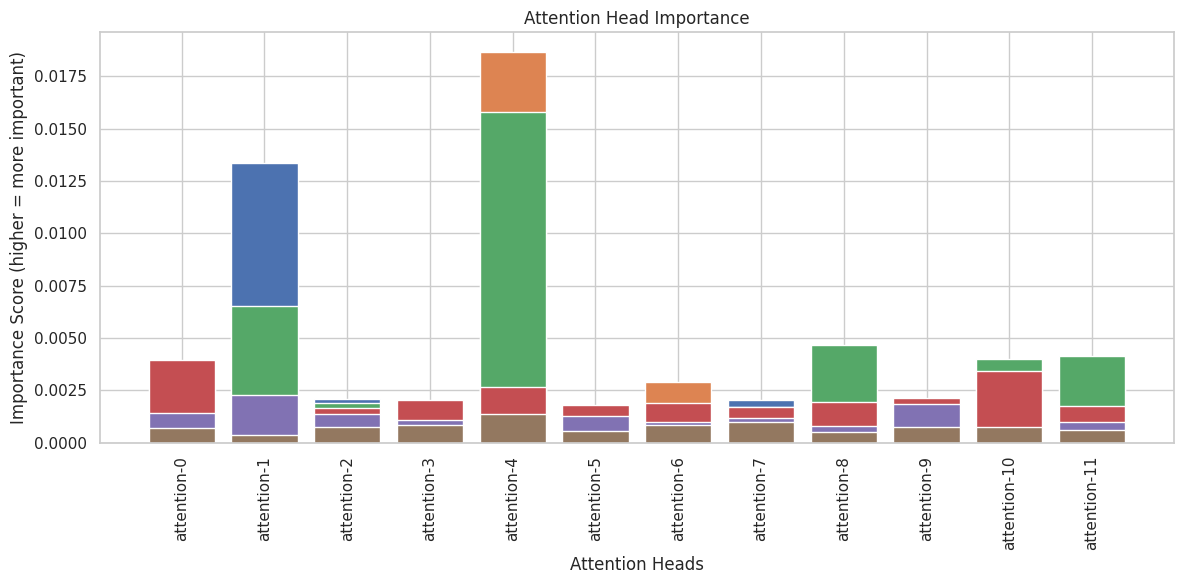

prune baby prune...21, 6
Pruning 21 heads with lowest importance scores
Pruning distilbert.transformer.layer.5.attention head 1 (importance: 0.000367)
Pruning distilbert.transformer.layer.5.attention head 8 (importance: 0.000498)
Pruning distilbert.transformer.layer.5.attention head 5 (importance: 0.000564)
Pruning distilbert.transformer.layer.5.attention head 11 (importance: 0.000607)
Pruning distilbert.transformer.layer.4.attention head 10 (importance: 0.000686)
Pruning distilbert.transformer.layer.5.attention head 0 (importance: 0.000723)
Pruning distilbert.transformer.layer.5.attention head 10 (importance: 0.000744)
Pruning distilbert.transformer.layer.5.attention head 9 (importance: 0.000758)
Pruning distilbert.transformer.layer.5.attention head 2 (importance: 0.000760)
Pruning distilbert.transformer.layer.4.attention head 8 (importance: 0.000801)
Pruning distilbert.transformer.layer.4.attention head 4 (importance: 0.000829)
Pruning distilbert.transformer.layer.5.attention head 6 

In [7]:
# Visualize head importance
plt.figure(figsize=(12, 6))
for module_name, importances in head_importance.items():
    module_name = module_name.split('.')[-1]  # Shorten the name
    plt.bar(
        [f"{module_name}-{i}" for i in range(len(importances))],
        importances
    )
plt.xticks(rotation=90)
plt.title("Attention Head Importance")
plt.xlabel("Attention Heads")
plt.ylabel("Importance Score (higher = more important)")
plt.tight_layout()
plt.show()

# TODO: Determine how many heads to prune based on a pruning rate
# Hint: Consider what percentage of heads you want to remove
pruning_rate = 0.3 #0.3  # 30% of heads will be pruned

# TODO: Calculate the number of heads to prune based on the pruning rate
# Hint: Count the total number of heads and apply the rate
n_heads_to_prune = int(sum(len(imp) for imp in head_importance.values()) * pruning_rate)
print(f'prune baby prune...{n_heads_to_prune}, {len(head_importance)}')

# Flatten and sort all heads by importance
all_heads = []
for module_name, importances in head_importance.items():
    for i, imp in enumerate(importances):
        all_heads.append((module_name, i, imp))

# TODO: Sort heads by importance to identify which to prune first
# Hint: Each item is a tuple of (module_name, head_idx, importance). Also, should you prune in ascending or descending order?
# Finally, feel free to sort in place instead!
all_heads.sort(key=lambda item: item[2])

# Get the least important heads
heads_to_prune = all_heads[:n_heads_to_prune]
print(f"Pruning {len(heads_to_prune)} heads with lowest importance scores")

# Print the heads to be pruned
for module_name, head_idx, imp in heads_to_prune:
    print(f"Pruning {module_name} head {head_idx} (importance: {imp:.6f})")

In [8]:
heads_to_prune

[('distilbert.transformer.layer.5.attention', 1, 0.00036718204501084983),
 ('distilbert.transformer.layer.5.attention', 8, 0.0004978742799721658),
 ('distilbert.transformer.layer.5.attention', 5, 0.0005638424772769213),
 ('distilbert.transformer.layer.5.attention', 11, 0.0006074215052649379),
 ('distilbert.transformer.layer.4.attention', 10, 0.0006864129682071507),
 ('distilbert.transformer.layer.5.attention', 0, 0.0007227536989375949),
 ('distilbert.transformer.layer.5.attention', 10, 0.0007442259229719639),
 ('distilbert.transformer.layer.5.attention', 9, 0.0007579574594274163),
 ('distilbert.transformer.layer.5.attention', 2, 0.0007596740615554154),
 ('distilbert.transformer.layer.4.attention', 8, 0.0008006982388906181),
 ('distilbert.transformer.layer.4.attention', 4, 0.0008291444974020123),
 ('distilbert.transformer.layer.5.attention', 6, 0.0008408150752075016),
 ('distilbert.transformer.layer.1.attention', 7, 0.0008411586168222129),
 ('distilbert.transformer.layer.5.attention', 3

In [9]:
len(heads_to_prune)

21

In [10]:
def prune_heads_in_model(model, heads_to_prune):
    """Prune attention heads in the model using Hugging Face's built-in method."""
    # Format the heads to prune into a dictionary that matches HuggingFace's format
    # {layer_num: [list of heads to prune in this layer]}
    pruning_dict = {}
    
    # Create a dictionary of heads to prune by layer index
    for module_name, head_idx, _ in heads_to_prune:
        # Extract layer index from module name (e.g., 'transformer.layer.0.attention')
        layer_parts = module_name.split('.')
        for i, part in enumerate(layer_parts):
            if part == 'layer' and i+1 < len(layer_parts) and layer_parts[i+1].isdigit():
                layer_idx = int(layer_parts[i+1])
                
                # TODO: Update the pruning dictionary for this layer for pruning
                # Hint: The expected output is a list. What would an empty list represent here?
                if layer_idx not in pruning_dict:
                    pruning_dict[layer_idx] = []
                pruning_dict[layer_idx].append(head_idx)
                break
    
    # Print the pruning plan
    print("Pruning plan:")
    for layer_idx, heads in pruning_dict.items():
        print(f"Layer {layer_idx}: Pruning heads {heads}")
    
    # Clone the model to avoid modifying the original
    pruned_model = type(model)(model.config)
    pruned_model.load_state_dict(model.state_dict())
    pruned_model = pruned_model.to(device)
    
    # Perform pruning layer by layer
    for layer_idx, heads in pruning_dict.items():
        # Find the attention module for this layer
        attention_module = None
        for name, module in pruned_model.named_modules():
            if f'layer.{layer_idx}.attention' in name and hasattr(module, 'prune_heads'):
                attention_module = module
                break
        
        if attention_module is not None:
            # TODO: Prune the defined attention heads for the module
            # Hint: Hugging Face provides a built-in functionality that updated attention_module in place!
            # See: https://huggingface.co/docs/transformers/main/main_classes/model
            # Add your one-line code here
            attention_module.prune_heads(heads)
        else:
            print(f"Warning: Could not find attention module for layer {layer_idx}")
    
    return pruned_model

# Prune the model
pruned_model = prune_heads_in_model(model, heads_to_prune)

Pruning plan:
Layer 5: Pruning heads [1, 8, 5, 11, 0, 10, 9, 2, 6, 3, 7]
Layer 4: Pruning heads [10, 8, 4, 11, 6, 3, 7]
Layer 1: Pruning heads [7, 2]
Layer 0: Pruning heads [11]


In [11]:
# Evaluate pruned model
print("Evaluating pruned model...")
pruned_metrics = evaluate_model(pruned_model, tokenizer, test_dataset, device)

print(f"Pruned model metrics:")
print(f"- Accuracy: {pruned_metrics['accuracy']:.4f}")
print(f"- Avg Latency: {pruned_metrics['avg_latency_ms']:.2f} ms")
print(f"- Model Size: {pruned_metrics['model_size_mb']:.2f} MB")

# Compare before and after pruning
print("\nComparison:")
print(f"Accuracy change: {(pruned_metrics['accuracy'] - original_metrics['accuracy']) * 100:.2f}%")
print(f"Latency improvement: {(1 - pruned_metrics['avg_latency_ms'] / original_metrics['avg_latency_ms']) * 100:.2f}%")
print(f"Size reduction: {(1 - pruned_metrics['model_size_mb'] / original_metrics['model_size_mb']) * 100:.2f}%")

Device set to use cpu


Evaluating pruned model...
Pruned model metrics:
- Accuracy: 0.8900
- Avg Latency: 33.63 ms
- Model Size: 239.65 MB

Comparison:
Accuracy change: -5.00%
Latency improvement: 11.13%
Size reduction: 6.17%


In [12]:
# Function to test sentiment analysis
def test_sentiment(model, tokenizer, sentences):
    """Test sentiment analysis on example sentences."""
    model.eval()
    pipeline = TextClassificationPipeline(
        model=model,
        tokenizer=tokenizer,
        device=device if device.type != "cpu" else -1
    )
    
    results = []
    for sentence in sentences:
        result = pipeline(sentence)
        label = result[0]['label']
        score = result[0]['score']
        results.append((sentence, label, score))
    
    return results

# Test with some examples
test_sentences = [
    "I really loved this movie, it was fantastic!",
    "The food was mediocre at best.",
    "This book changed my life in many positive ways.",
    "I'm feeling extremely disappointed with the service provided."
]

print("\nTesting original model:")
original_results = test_sentiment(model, tokenizer, test_sentences)
for sentence, label, score in original_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

print("\nTesting pruned model:")
pruned_results = test_sentiment(pruned_model, tokenizer, test_sentences)
for sentence, label, score in pruned_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

Device set to use cpu
Device set to use cpu



Testing original model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9999)
'The food was mediocre at best.' -> NEGATIVE (0.9996)
'This book changed my life in many positive ways.' -> POSITIVE (0.9998)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9998)

Testing pruned model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9987)
'The food was mediocre at best.' -> NEGATIVE (0.9778)
'This book changed my life in many positive ways.' -> POSITIVE (0.9955)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9764)


In [13]:
import os
import time
import math
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from transformers import AutoModelForCausalLM, AutoTokenizer

In [14]:
MLP_PRUNE_FRAC = 0.2
MLP_PRUNE_FRAC

0.2

In [15]:
def prune_mlp_rows_and_cols(model: nn.Module, prune_frac: float):
    """
    TODO:
      - Move model to CPU
      - For each layer in model.model.layers:
          • Zero out `prune_frac` of rows in gate_proj and up_proj
          • Zero out corresponding `prune_frac` of columns in down_proj
      - Remove pruning reparameterizations
    """
    # 1) Ensure we prune on CPU to avoid GPU OOM
    model.cpu()
    torch.cuda.empty_cache()
    n = 0

    # 2) Iterate through each decoder layer’s MLP
    for layer in model.distilbert.transformer.layer:
        n += 1
        #if n > 1:
        #    prune_frac=0.2
        #if n > 5:
        #    return model
        lin1 = layer.ffn.lin1   # [inner, hidden]
        #lin2   = layer.ffn.lin2    # [inner, hidden]
        
        # 2) Zero out rows in gate_proj and up_proj
        prune.ln_structured(
            lin1,
            name="weight",
            amount=prune_frac,
            n=1,
            dim=0,           # prune entire rows
            )
        prune.remove(lin1, "weight")

     # 3) Return the model (now with zeros in place)
    return model

In [16]:
#import copy
#pruned_model = copy.deepcopy(model)

In [17]:
prune_mlp_rows_and_cols(pruned_model, MLP_PRUNE_FRAC)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=704, bias=True)
            (k_lin): Linear(in_features=768, out_features=704, bias=True)
            (v_lin): Linear(in_features=768, out_features=704, bias=True)
            (out_lin): Linear(in_features=704, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
      

In [18]:
# Check state before pruning
print("AFTER STRUCTURED PRUNING:\n")
# Model State
#print(f"Model parameters: {[name for name, _ in pruned_model.named_parameters()]}")
print(f"Model buffers: {[name for name, _ in pruned_model.named_buffers()]}")

AFTER STRUCTURED PRUNING:

Model buffers: ['distilbert.embeddings.position_ids']


In [19]:
def rebuild_mlp_blocks(model):
    """
    TODO:
      - For each layer in model.model.layers:
          1) Identify kept neuron indices in gate_proj
          2) Construct new nn.Linear modules for gate_proj, up_proj, down_proj
             with reduced dimensions
          3) Copy over weights and biases
          4) Replace the old modules on the model
    """
    n = 0
    for layer in model.distilbert.transformer.layer:
        # original modules (still on CPU, dtype=original)
        n += 1
        #if n > 5:
        #    return model
        old_gate = layer.ffn.lin1
        #old_up   = layer.mlp.up_proj
        old_down = layer.ffn.lin2

        # discover surviving rows in gate_proj
        Wg = old_gate.weight.data     # [inner_orig, hidden], dtype say torch.half
        keep_idx = (Wg.abs().sum(dim=1) != 0).nonzero(as_tuple=False).view(-1)
        inner_new = keep_idx.numel()
        hidden    = Wg.size(1)
        dtype     = Wg.dtype
        device    = Wg.device

        # helper to build a new Linear with the same dtype/device
        def make_linear(in_f, out_f, bias, old_weight, old_bias=None):
            nl = nn.Linear(in_f, out_f, bias=bias)
            # init in correct dtype & device
            nl.weight.data = old_weight.clone().to(device=device, dtype=dtype)
            if bias and old_bias is not None:
                nl.bias.data = old_bias.clone().to(device=device, dtype=dtype)
            return nl

        # rebuild gate_proj: hidden -> inner_new
        new_gate = make_linear(
            hidden, inner_new, 
            bias=(old_gate.bias is not None),
            old_weight=old_gate.weight.data[keep_idx],
            old_bias=old_gate.bias.data[keep_idx] if old_gate.bias is not None else None
        )

      # rebuild down_proj: inner_new -> hidden
        new_down = make_linear(
            inner_new, hidden,
            bias=(old_down.bias is not None),
            old_weight=old_down.weight.data[:, keep_idx],
            old_bias=old_down.bias.data if old_down.bias is not None else None
        )

        # swap in-place
        layer.ffn.lin1 = new_gate
        layer.ffn.lin2 = new_down

    return model

In [20]:
rebuild_mlp_blocks(pruned_model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=704, bias=True)
            (k_lin): Linear(in_features=768, out_features=704, bias=True)
            (v_lin): Linear(in_features=768, out_features=704, bias=True)
            (out_lin): Linear(in_features=704, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
      

In [21]:
for layer in pruned_model.distilbert.transformer.layer :#[0].ffn
    print(layer.ffn.lin1)
    print(layer.ffn.lin2)
    print("###########")

Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########
Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########
Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########
Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########
Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########
Linear(in_features=768, out_features=2458, bias=True)
Linear(in_features=2458, out_features=768, bias=True)
###########


In [22]:
# Evaluate pruned model
print("Evaluating pruned model...")
pruned_metrics = evaluate_model(pruned_model, tokenizer, test_dataset, device)

print(f"Pruned model metrics:")
print(f"- Accuracy: {pruned_metrics['accuracy']:.4f}")
print(f"- Avg Latency: {pruned_metrics['avg_latency_ms']:.2f} ms")
print(f"- Model Size: {pruned_metrics['model_size_mb']:.2f} MB")

# Compare before and after pruning
print("\nComparison:")
print(f"Accuracy change: {(pruned_metrics['accuracy'] - original_metrics['accuracy']) * 100:.2f}%")
print(f"Latency improvement: {(1 - pruned_metrics['avg_latency_ms'] / original_metrics['avg_latency_ms']) * 100:.2f}%")
print(f"Size reduction: {(1 - pruned_metrics['model_size_mb'] / original_metrics['model_size_mb']) * 100:.2f}%")

Device set to use cpu


Evaluating pruned model...
Pruned model metrics:
- Accuracy: 0.8500
- Avg Latency: 25.82 ms
- Model Size: 218.05 MB

Comparison:
Accuracy change: -9.00%
Latency improvement: 31.77%
Size reduction: 14.63%


In [23]:
# Function to test sentiment analysis
def test_sentiment(model, tokenizer, sentences):
    """Test sentiment analysis on example sentences."""
    model.eval()
    pipeline = TextClassificationPipeline(
        model=model,
        tokenizer=tokenizer,
        device=device if device.type != "cpu" else -1
    )
    
    results = []
    for sentence in sentences:
        result = pipeline(sentence)
        label = result[0]['label']
        score = result[0]['score']
        results.append((sentence, label, score))
    
    return results

# Test with some examples
test_sentences = [
    "I really loved this movie, it was fantastic!",
    "The food was mediocre at best.",
    "This book changed my life in many positive ways.",
    "I'm feeling extremely disappointed with the service provided."
]

print("\nTesting original model:")
original_results = test_sentiment(model, tokenizer, test_sentences)
for sentence, label, score in original_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

print("\nTesting pruned model:")
pruned_results = test_sentiment(pruned_model, tokenizer, test_sentences)
for sentence, label, score in pruned_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

Device set to use cpu
Device set to use cpu



Testing original model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9999)
'The food was mediocre at best.' -> NEGATIVE (0.9996)
'This book changed my life in many positive ways.' -> POSITIVE (0.9998)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9998)

Testing pruned model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9932)
'The food was mediocre at best.' -> NEGATIVE (0.7341)
'This book changed my life in many positive ways.' -> POSITIVE (0.9582)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9174)


In [24]:
quantized_dynamic_model = torch.quantization.quantize_dynamic(
        pruned_model,
        {nn.Linear},
        dtype=torch.qint8
    )

In [25]:
# Evaluate pruned model
print("Evaluating quantized model...")
quant_metrics = evaluate_model(quantized_dynamic_model, tokenizer, test_dataset, device)

print(f"Pruned model metrics:")
print(f"- Accuracy: {quant_metrics['accuracy']:.4f}")
print(f"- Avg Latency: {quant_metrics['avg_latency_ms']:.2f} ms")
print(f"- Model Size: {quant_metrics['model_size_mb']:.2f} MB")

# Compare before and after pruning
print("\nComparison:")
print(f"Accuracy change: {(quant_metrics['accuracy'] - original_metrics['accuracy']) * 100:.2f}%")
print(f"Latency improvement: {(1 - quant_metrics['avg_latency_ms'] / original_metrics['avg_latency_ms']) * 100:.2f}%")
print(f"Size reduction: {(1 - quant_metrics['model_size_mb'] / original_metrics['model_size_mb']) * 100:.2f}%")

Device set to use cpu


Evaluating quantized model...
Pruned model metrics:
- Accuracy: 0.8500
- Avg Latency: 11.79 ms
- Model Size: 91.00 MB

Comparison:
Accuracy change: -9.00%
Latency improvement: 68.84%
Size reduction: 64.37%


In [26]:
# Function to test sentiment analysis
def test_sentiment(model, tokenizer, sentences):
    """Test sentiment analysis on example sentences."""
    model.eval()
    pipeline = TextClassificationPipeline(
        model=model,
        tokenizer=tokenizer,
        device=device if device.type != "cpu" else -1
    )
    
    results = []
    for sentence in sentences:
        result = pipeline(sentence)
        label = result[0]['label']
        score = result[0]['score']
        results.append((sentence, label, score))
    
    return results

# Test with some examples
test_sentences = [
    "I really loved this movie, it was fantastic!",
    "The food was mediocre at best.",
    "This book changed my life in many positive ways.",
    "I'm feeling extremely disappointed with the service provided."
]

print("\nTesting original model:")
original_results = test_sentiment(model, tokenizer, test_sentences)
for sentence, label, score in original_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

print("\nTesting pruned model:")
pruned_results = test_sentiment(quantized_dynamic_model, tokenizer, test_sentences)
for sentence, label, score in pruned_results:
    print(f"'{sentence}' -> {label} ({score:.4f})")

Device set to use cpu
Device set to use cpu



Testing original model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9999)
'The food was mediocre at best.' -> NEGATIVE (0.9996)
'This book changed my life in many positive ways.' -> POSITIVE (0.9998)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9998)

Testing pruned model:
'I really loved this movie, it was fantastic!' -> POSITIVE (0.9904)
'The food was mediocre at best.' -> NEGATIVE (0.8530)
'This book changed my life in many positive ways.' -> POSITIVE (0.9288)
'I'm feeling extremely disappointed with the service provided.' -> NEGATIVE (0.9316)
